# Energy consumption prediction project

### Importing necessary libraries and Loading datasets

In [176]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [177]:
train_data= pd.read_csv('train_energy_data.csv')
train_data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [178]:
test_data= pd.read_csv('test_energy_data.csv')
test_data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


### Seeing basic info from Train Data

In [179]:
train_data.shape

(1000, 7)

In [180]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB


In [181]:
# see the features of train data
train_data.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='str')

In [182]:
# Summary of train data
train_data.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [183]:
# 
num_cols = train_data.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols

['Square Footage',
 'Number of Occupants',
 'Appliances Used',
 'Average Temperature',
 'Energy Consumption']

In [184]:
cat_cols = train_data.select_dtypes(include=['str']).columns.tolist()
cat_cols

['Building Type', 'Day of Week']

## Data cleaning

In [185]:
train_data.isnull().sum().sum()

np.int64(0)

In [186]:
test_data.isnull().sum().sum()

np.int64(0)

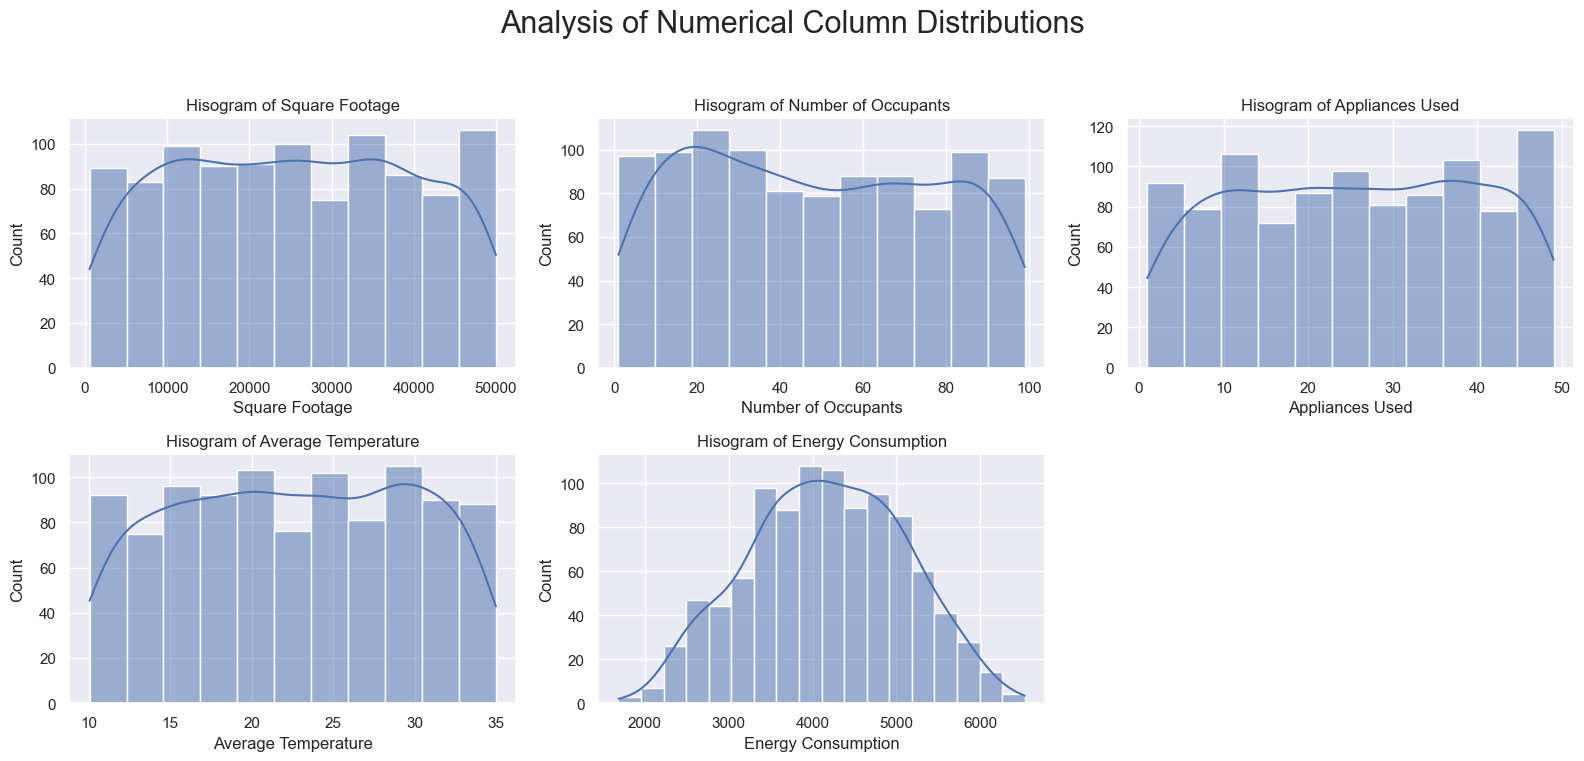

In [187]:
plt.figure(figsize=(16,8))
plt.suptitle("Analysis of Numerical Column Distributions", fontsize=22)

for i,col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(train_data[col], kde=True)
    plt.title(f"Hisogram of {col}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

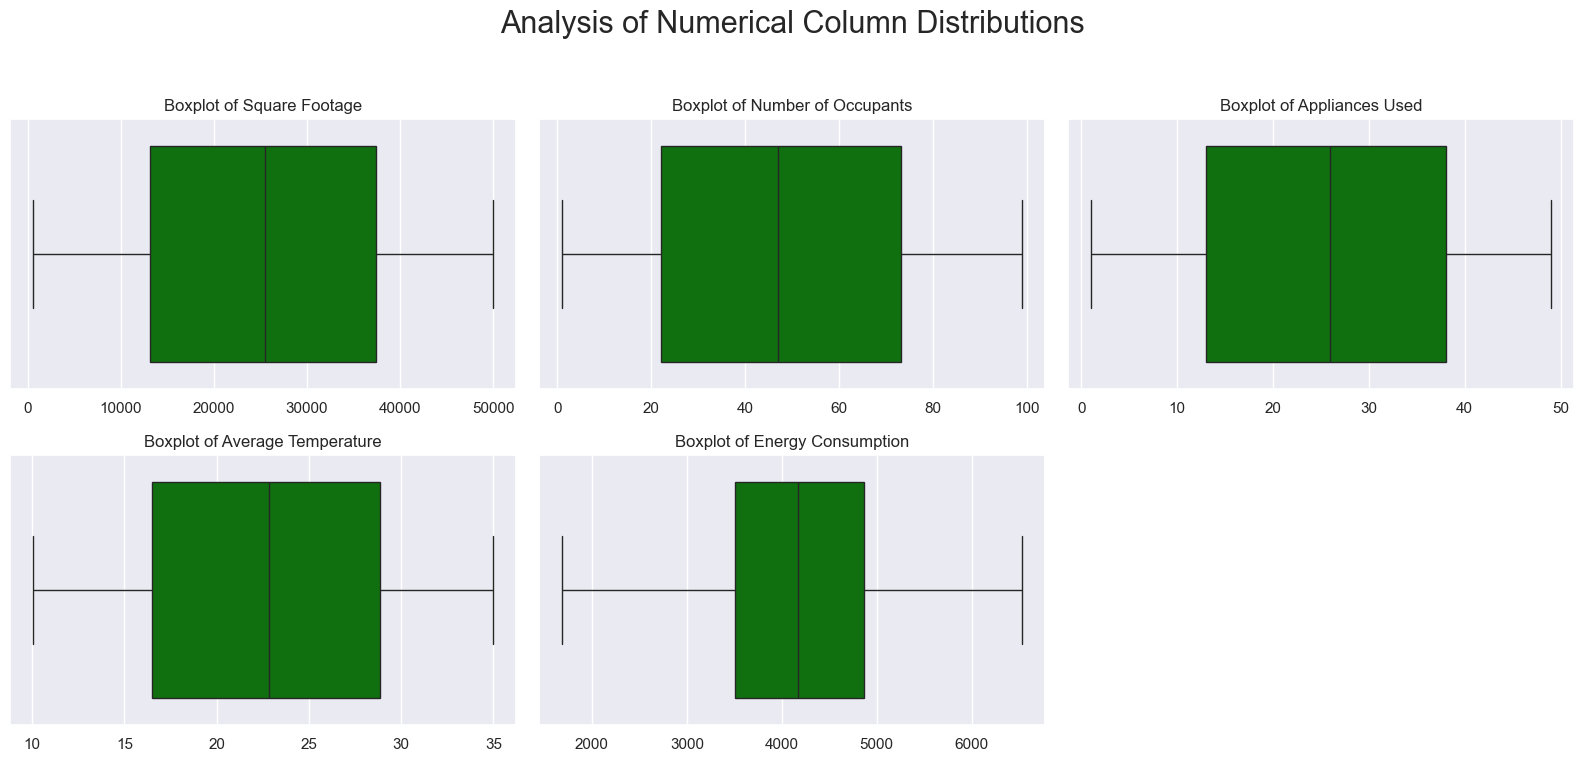

In [188]:
plt.figure(figsize=(16,8))  # Adjust height based on number of rows
plt.suptitle("Analysis of Numerical Column Distributions", fontsize=22)

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=train_data, x=col, color='green')
    plt.title(f"Boxplot of {col}")
    plt.xlabel("") # Keeps the plot clean

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

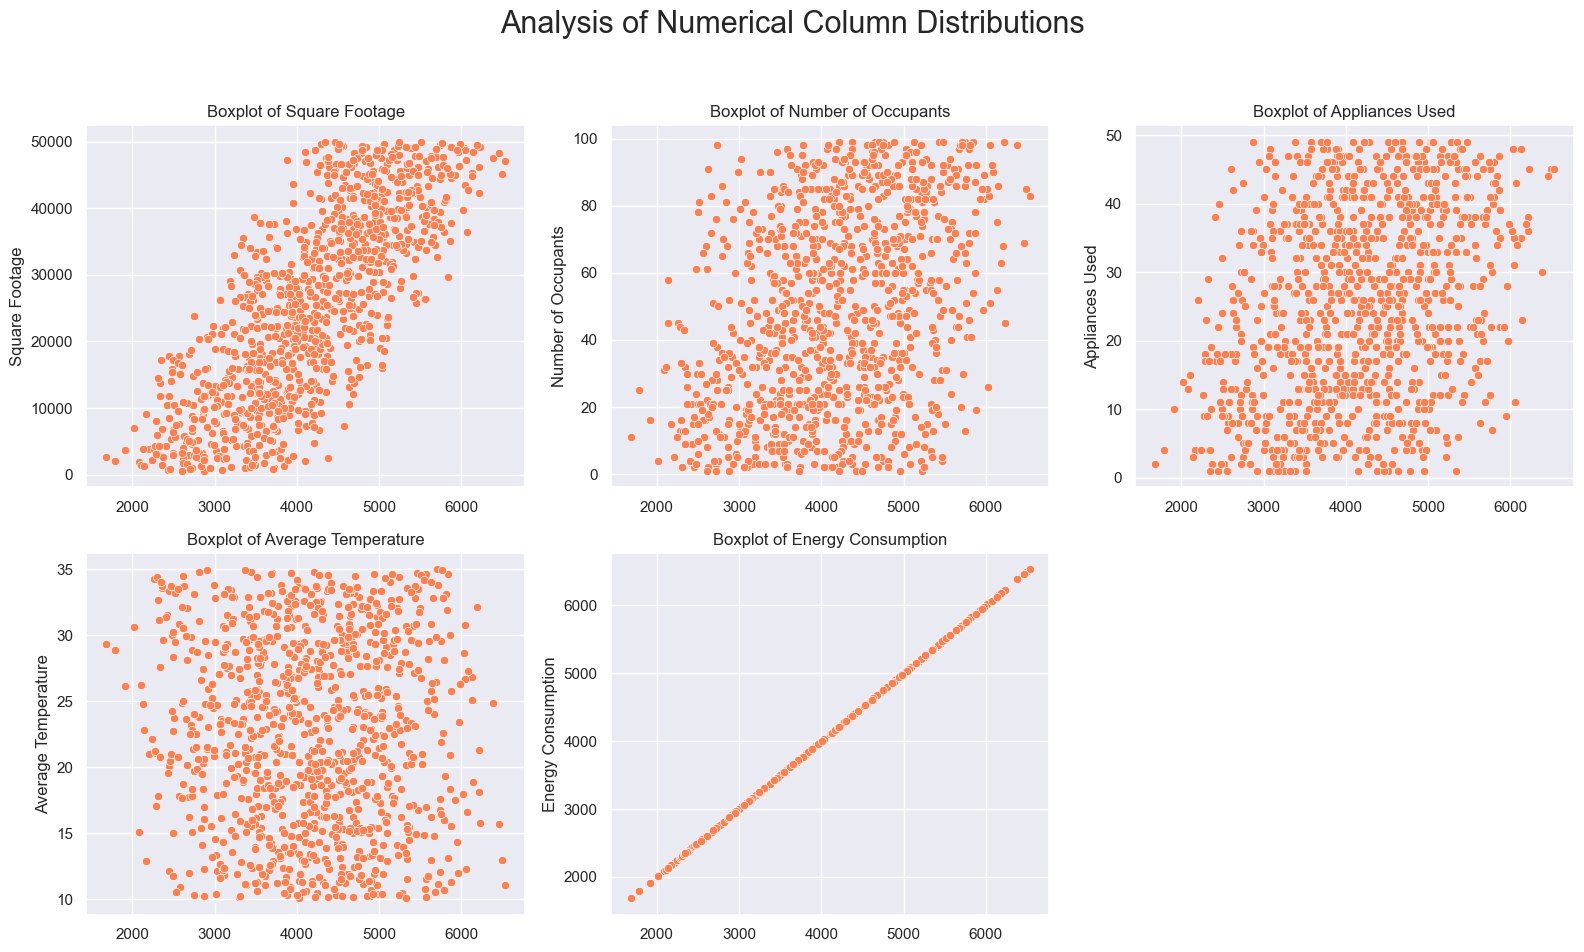

In [189]:
plt.figure(figsize=(16,10))  # Adjust height based on number of rows
sns.set_theme(style="darkgrid")
plt.suptitle("Analysis of Numerical Column Distributions", fontsize=22)

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=train_data, x=train_data['Energy Consumption'], y=col, color='coral')
    plt.title(f"Boxplot of {col}")
    plt.xlabel("") # Keeps the plot clean

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

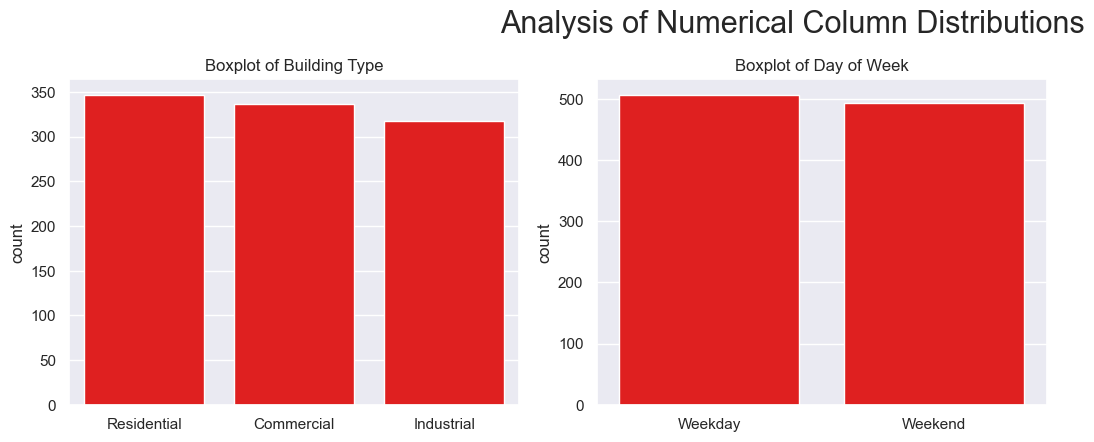

In [190]:
plt.figure(figsize=(16,8))  # Adjust height based on number of rows
plt.suptitle("Analysis of Numerical Column Distributions", fontsize=22)

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=train_data, x=col, color='red')
    plt.title(f"Boxplot of {col}")
    plt.xlabel("") # Keeps the plot clean

plt.tight_layout() # Adjust for suptitle
plt.show()


## Defining dependent and independent variables 

In [191]:
X = train_data.drop("Energy Consumption", axis=1)
y= train_data["Energy Consumption"]

## Spliting the dataset

In [192]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Data preprocessing

In [193]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# encode categorical part
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [194]:
# drop categorical columns
X_train_num = X_train.drop(columns=cat_cols)
X_test_num = X_test.drop(columns=cat_cols)

# convert encoded arrays to DataFrame
cat_features = ohe.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=cat_features, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_features, index=X_test.index)

# combine
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

In [195]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)  # FIX: Changed from fit_transform to transform (avoid data leakage - scaler should only fit on training data)

## Model training

In [196]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [197]:
y_pred_test= model.predict(X_test)
y_pred_train= model.predict(X_train)

In [198]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# 1. Calculate Mean Absolute Error (Average error in same units as Energy)
mae_train = mean_absolute_error(y_train, y_pred_train) 
mae_test = mean_absolute_error(y_test, y_pred_test) 

# 2. Calculate Mean Squared Error & Root Mean Squared Error
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)  # FIX: Changed from mse_train to mse_test (was using wrong variable)

# 3. Calculate R-squared (How much variance your model explains: 1.0 is perfect)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

adjusted_r2_train=1-(1-r2_train)*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1)
adjusted_r2_test=1-(1-r2_test)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

print('Evaluation metrics on Train Data')
print(f"MAE: {mae_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R2 Score: {r2_train:.4f}")
print(f"Adjudted_R2 Score: {adjusted_r2_train:.4f}")

print('-----'*7)
print('-----'*12)
print('-----'*7)
print('Evaluation metrics on Test Data')
print(f"MAE: {mae_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R2 Score: {r2_test:.4f}")
print(f"Adjudted_R2 Score: {adjusted_r2_test:.4f}")


Evaluation metrics on Train Data
MAE: 0.01
RMSE: 0.01
R2 Score: 1.0000
Adjudted_R2 Score: 1.0000
-----------------------------------
------------------------------------------------------------
-----------------------------------
Evaluation metrics on Test Data
MAE: 0.01
RMSE: 0.01
R2 Score: 1.0000
Adjudted_R2 Score: 1.0000


## Testing with unseen test dataset

In [199]:
unseen_X = test_data.drop("Energy Consumption", axis=1)
unseen_y = test_data['Energy Consumption']

In [200]:
# Apply encoding to categorical columns
unseen_X_cat = ohe.transform(unseen_X[cat_cols])

# Drop categorical columns from unseen data
unseen_X_num = unseen_X.drop(columns=cat_cols)

# Convert encoded arrays to DataFrame
unseen_X_cat = pd.DataFrame(unseen_X_cat, columns=cat_features, index=unseen_X.index)

# Combine numerical and encoded categorical data
unseen_X_combined = pd.concat([unseen_X_num, unseen_X_cat], axis=1)

# Apply scaling (use transform only, not fit_transform, since scaler is already fitted)
unseen_X_scaled = scaler.transform(unseen_X_combined)

# Convert to DataFrame
unseen_X = pd.DataFrame(unseen_X_scaled, columns=unseen_X_combined.columns)

unseen_X.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Commercial,Building Type_Industrial,Building Type_Residential,Day of Week_Weekday,Day of Week_Weekend
0,-0.060661,-1.139028,-1.507894,0.824061,-0.703943,-0.685053,1.365008,0.950478,-0.950478
1,0.149174,0.252155,-0.167614,0.062247,1.420570,-0.685053,-0.732596,-1.052102,1.052102
2,1.381089,-1.512272,1.313748,1.528565,1.420570,-0.685053,-0.732596,0.950478,-0.950478
3,1.124840,1.202231,-0.590860,0.666107,-0.703943,-0.685053,1.365008,-1.052102,1.052102
4,0.784031,0.320018,1.525371,-0.775050,-0.703943,-0.685053,1.365008,0.950478,-0.950478


In [201]:
# Make predictions on unseen test data
unseen_y_pred = model.predict(unseen_X)

# Calculate evaluation metrics
mae_unseen = mean_absolute_error(unseen_y, unseen_y_pred) 
mse_unseen = mean_squared_error(unseen_y, unseen_y_pred)
rmse_unseen = np.sqrt(mse_unseen)
r2_unseen = r2_score(unseen_y, unseen_y_pred)
adjusted_r2_unseen = 1 - (1 - r2_unseen) * (len(unseen_y) - 1) / (len(unseen_y) - unseen_X.shape[1] - 1)

# Display results
print('Evaluation metrics on Unseen Test Data')
print(f"MAE: {mae_unseen:.2f}")
print(f"RMSE: {rmse_unseen:.2f}")
print(f"R2 Score: {r2_unseen:.4f}")
print(f"Adjusted_R2 Score: {adjusted_r2_unseen:.4f}")

Evaluation metrics on Unseen Test Data
MAE: 0.01
RMSE: 0.01
R2 Score: 1.0000
Adjusted_R2 Score: 1.0000


In [202]:
## DIAGNOSTIC: Check if predictions are actually matching values

# Check train data
print("Train Data - First 10 samples:")
print("Actual:   ", y_train.values[:10])
print("Predicted:", y_pred_train[:10])
print("Match?", np.allclose(y_train.values[:10], y_pred_train[:10]))

print("\n" + "="*50 + "\n")

# Check test data  
print("Test Data - First 10 samples:")
print("Actual:   ", y_test.values[:10])
print("Predicted:", y_pred_test[:10])
print("Match?", np.allclose(y_test.values[:10], y_pred_test[:10]))

print("\n" + "="*50 + "\n")

# Check unseen data
print("Unseen Data - First 10 samples:")
print("Actual:   ", unseen_y.values[:10])
print("Predicted:", unseen_y_pred[:10])
print("Match?", np.allclose(unseen_y.values[:10], unseen_y_pred[:10]))

Train Data - First 10 samples:
Actual:    [3419.14 4969.79 5438.11 4680.87 2713.95 3109.29 5268.16 5513.36 3724.42
 4726.97]
Predicted: [3419.14945926 4969.80168252 5438.10069319 4680.85106605 2713.95021328
 3109.30007822 5268.14923924 5513.35016655 3724.40000761 4726.95043669]
Match? True


Test Data - First 10 samples:
Actual:    [4549.59 2842.91 5781.83 4773.54 3791.04 2470.59 5003.05 3314.12 5147.11
 4298.92]
Predicted: [4549.59833373 2842.90155792 5781.84768187 4773.5509501  3791.04971172
 2470.59936339 5003.04886988 3314.10041559 5147.09922326 4298.90061916]
Match? True


Unseen Data - First 10 samples:
Actual:    [2865.57 4283.8  5067.83 4624.3  4820.59 5026.23 4404.56 2394.37 3969.09
 5136.69]
Predicted: [2865.55013547 4283.79895446 5067.85013418 4624.29817713 4820.60135675
 5026.25094115 4404.54916545 2394.35071775 3969.09922566 5136.70182481]
Match? True


## Hyperparameter Tuning

In [207]:
from sklearn.linear_model import Ridge, Lasso

# Train Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Make predictions with Ridge
ridge_y_pred_train = ridge_model.predict(X_train)
ridge_y_pred_test = ridge_model.predict(X_test)
ridge_unseen_y_pred = ridge_model.predict(unseen_X_scaled)

# Train Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# Make predictions with Lasso
lasso_y_pred_train = lasso_model.predict(X_train)
lasso_y_pred_test = lasso_model.predict(X_test)
lasso_unseen_y_pred = lasso_model.predict(unseen_X_scaled)

In [208]:
# RIDGE REGRESSION EVALUATION
print("="*70)
print("RIDGE REGRESSION EVALUATION")
print("="*70)

# Ridge Train metrics
ridge_mae_train = mean_absolute_error(y_train, ridge_y_pred_train)
ridge_mse_train = mean_squared_error(y_train, ridge_y_pred_train)
ridge_rmse_train = np.sqrt(ridge_mse_train)
ridge_r2_train = r2_score(y_train, ridge_y_pred_train)
ridge_adj_r2_train = 1 - (1 - ridge_r2_train) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1)

print('\nRIDGE - Train Data:')
print(f"MAE: {ridge_mae_train:.2f}")
print(f"RMSE: {ridge_rmse_train:.2f}")
print(f"R2 Score: {ridge_r2_train:.4f}")
print(f"Adjusted R2 Score: {ridge_adj_r2_train:.4f}")

# Ridge Test metrics
ridge_mae_test = mean_absolute_error(y_test, ridge_y_pred_test)
ridge_mse_test = mean_squared_error(y_test, ridge_y_pred_test)
ridge_rmse_test = np.sqrt(ridge_mse_test)
ridge_r2_test = r2_score(y_test, ridge_y_pred_test)
ridge_adj_r2_test = 1 - (1 - ridge_r2_test) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print('\nRIDGE - Test Data:')
print(f"MAE: {ridge_mae_test:.2f}")
print(f"RMSE: {ridge_rmse_test:.2f}")
print(f"R2 Score: {ridge_r2_test:.4f}")
print(f"Adjusted R2 Score: {ridge_adj_r2_test:.4f}")

# Ridge Unseen metrics
ridge_mae_unseen = mean_absolute_error(unseen_y, ridge_unseen_y_pred)
ridge_mse_unseen = mean_squared_error(unseen_y, ridge_unseen_y_pred)
ridge_rmse_unseen = np.sqrt(ridge_mse_unseen)
ridge_r2_unseen = r2_score(unseen_y, ridge_unseen_y_pred)
ridge_adj_r2_unseen = 1 - (1 - ridge_r2_unseen) * (len(unseen_y) - 1) / (len(unseen_y) - unseen_X_scaled.shape[1] - 1)

print('\nRIDGE - Unseen Data:')
print(f"MAE: {ridge_mae_unseen:.2f}")
print(f"RMSE: {ridge_rmse_unseen:.2f}")
print(f"R2 Score: {ridge_r2_unseen:.4f}")
print(f"Adjusted R2 Score: {ridge_adj_r2_unseen:.4f}")

print("\n" + "="*70)
print("LASSO REGRESSION EVALUATION")
print("="*70)

# Lasso Train metrics
lasso_mae_train = mean_absolute_error(y_train, lasso_y_pred_train)
lasso_mse_train = mean_squared_error(y_train, lasso_y_pred_train)
lasso_rmse_train = np.sqrt(lasso_mse_train)
lasso_r2_train = r2_score(y_train, lasso_y_pred_train)
lasso_adj_r2_train = 1 - (1 - lasso_r2_train) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1)

print('\nLASSO - Train Data:')
print(f"MAE: {lasso_mae_train:.2f}")
print(f"RMSE: {lasso_rmse_train:.2f}")
print(f"R2 Score: {lasso_r2_train:.4f}")
print(f"Adjusted R2 Score: {lasso_adj_r2_train:.4f}")

# Lasso Test metrics
lasso_mae_test = mean_absolute_error(y_test, lasso_y_pred_test)
lasso_mse_test = mean_squared_error(y_test, lasso_y_pred_test)
lasso_rmse_test = np.sqrt(lasso_mse_test)
lasso_r2_test = r2_score(y_test, lasso_y_pred_test)
lasso_adj_r2_test = 1 - (1 - lasso_r2_test) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print('\nLASSO - Test Data:')
print(f"MAE: {lasso_mae_test:.2f}")
print(f"RMSE: {lasso_rmse_test:.2f}")
print(f"R2 Score: {lasso_r2_test:.4f}")
print(f"Adjusted R2 Score: {lasso_adj_r2_test:.4f}")

# Lasso Unseen metrics
lasso_mae_unseen = mean_absolute_error(unseen_y, lasso_unseen_y_pred)
lasso_mse_unseen = mean_squared_error(unseen_y, lasso_unseen_y_pred)
lasso_rmse_unseen = np.sqrt(lasso_mse_unseen)
lasso_r2_unseen = r2_score(unseen_y, lasso_unseen_y_pred)
lasso_adj_r2_unseen = 1 - (1 - lasso_r2_unseen) * (len(unseen_y) - 1) / (len(unseen_y) - unseen_X_scaled.shape[1] - 1)

print('\nLASSO - Unseen Data:')
print(f"MAE: {lasso_mae_unseen:.2f}")
print(f"RMSE: {lasso_rmse_unseen:.2f}")
print(f"R2 Score: {lasso_r2_unseen:.4f}")
print(f"Adjusted R2 Score: {lasso_adj_r2_unseen:.4f}")

RIDGE REGRESSION EVALUATION

RIDGE - Train Data:
MAE: 1.06
RMSE: 1.26
R2 Score: 1.0000
Adjusted R2 Score: 1.0000

RIDGE - Test Data:
MAE: 0.97
RMSE: 1.17
R2 Score: 1.0000
Adjusted R2 Score: 1.0000

RIDGE - Unseen Data:
MAE: 0.92
RMSE: 1.10
R2 Score: 1.0000
Adjusted R2 Score: 1.0000

LASSO REGRESSION EVALUATION

LASSO - Train Data:
MAE: 0.19
RMSE: 0.24
R2 Score: 1.0000
Adjusted R2 Score: 1.0000

LASSO - Test Data:
MAE: 0.19
RMSE: 0.23
R2 Score: 1.0000
Adjusted R2 Score: 1.0000

LASSO - Unseen Data:
MAE: 0.19
RMSE: 0.23
R2 Score: 1.0000
Adjusted R2 Score: 1.0000


## No need to do tuning.
### Our data is working correctly and giving max result beacuse there is strong relatoinship between the features